In [1]:
import numpy as np
import pandas as pd 
import math 
import matplotlib.pyplot as plt 


In [ ]:
# INITIALISE LATTICE: 

def create_grid(size, mode="random",seed=None,rng=None): 
    #creates an nxn numpy grid and initialises random parameters 

    if rng == None:
        rng = np.random.default_rng(seed)

    if mode == "random":
        grid = rng.choice([-1,1],size=(size,size))
    elif mode == "up":
        grid = np.ones((size,size), dtype=int)
    elif mode == "down":
        grid = -np.ones((size,size), dtype=int)
    else:
        raise ValueError("Mode must be: up, random, down")

    return grid 

# COMPUTE ENERGY AND BOUNDARY CONDITIONS (HAMILTONIAN): 

def total_energy(spins, J=1.0, h=0.0): 

    #computes periodic boundary conditions (wraps around)
    right = np.roll(spins, shift=-1, axis=1)
    down = np.roll(spins, shift=-1, axis=0)

    interaction = -J * np.sum(spins * (right + down))
    field_term = -h * np.sum(spins)

    return interaction + field_term
    
# CALCULATE CHANGE IN ENERGY BY CHANGING ONE SPIN

def delta_energy(spins, i, j, J=1.0, h=0.0): 

    L = spins.shape[0]
    s = spins[i, j]

    # periodic neighbours
    up    = spins[(i - 1) % L, j]
    down  = spins[(i + 1) % L, j]
    left  = spins[i, (j - 1) % L]
    right = spins[i, (j + 1) % L]

    S = up + down + left + right

    return 2 * s * (J * S + h)

# CALCULATE MAGNETISATION

def magnetisation(spins):
    return np.mean(spins)

# RUN ONE METROPOLIS SWEEP (LxL)

def metropolis_sweep(spins, T, J=1.0, h=0.0, update_rule=None, rng=None): 
    if rng is None:
        rng = np.random.default_rng()

    L = spins.shape[0]
    N = spins.size 

    for _ in range(N):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        dE = delta_energy(spins, i, j, J=J, h=h)

        if dE <= 0:
            spins[i, j] *= -1
        else:
            if rng.random() < np.exp(-dE / T):
                spins[i, j] *= -1

    return spins

# GET ROLLING VOLATILITY FROM RETURNS

def rolling_volatility(r, window=10):
    vol = np.full(len(r),np.nan)
    
    for t in range(window, len(r)):
        window_data = r[t-window:t]   # ONLY past values
        vol[t] = np.std(window_data)
        
    return vol

#GET NON-ROLLING VOL FROM RETURNS

def non_overlapping_volatility(r, window=10, ddof=1):
    r = np.asarray(r)
    
    n_blocks = len(r) // window
    trimmed = r[:n_blocks * window]              # drop leftover values
    blocks = trimmed.reshape(n_blocks, window)   # shape = (n_blocks, window)
    
    vol = np.std(blocks, axis=1, ddof=ddof)
    return vol

# RUN SIMULATION 

def run_simulation(
    L=75,
    T=2.27,
    J=1.0,
    h=0.0,
    n_equil=1000,
    n_steps=1500,
    sample_freq=10,
    init_mode="random",
    seed=None
):
    rng = np.random.default_rng(seed)

    print(f"[T={T}] Initialising lattice...")
    spins = create_grid(L, mode=init_mode, seed=seed, rng=rng)

    print(f"[T={T}] Running equilibration sweeps ({n_equil})...")
    for i in range(n_equil):
        metropolis_sweep(spins, T, J=J, h=h, rng=rng)

    print(f"[T={T}] Starting main simulation ({n_steps} steps)...")

    mags = []
    energies = []
    first_returns = []
   
    # define 4 checkpoints for progress updates
    checkpoints = set([
        int(n_steps * 0.25),
        int(n_steps * 0.5),
        int(n_steps * 0.75),
        int(n_steps * 1.0)
    ])

    for i in range(n_steps):
        metropolis_sweep(spins, T, J=J, h=h, rng=rng)

        if i % sample_freq == 0:
            current_mags = float(magnetisation(spins))

            if len(mags) > 0:
                first_returns.append(float(current_mags - mags[-1]))


            energies.append(total_energy(spins, J=J, h=h))
            mags.append(current_mags)

        # clean progress updates (~4 total)
        if (i + 1) in checkpoints:
            progress = int(((i + 1) / n_steps) * 100)
            print(f"[T={T}] Progress: {progress}%")

    print(f"[T={T}] Simulation complete.\n")

    return spins, np.array(mags), np.array(energies), np.array(first_returns), np.array(rolling_volatility(first_returns,window=20)), np.array(non_overlapping_volatility(first_returns))


In [3]:
#RUN THE SIMULATION AT SEVERAL TEMPERATURES AND EXTRACT BASIC METRICS: 


temps = [1.0, 1.5, 2.0, 2.1, 2.15, 2.2, 2.24, 2.26, 2.269, 2.28, 2.3, 2.35, 2.5, 3.0, 4.0]

results = {}
L = 32

for t in temps: 
    spins, mags, energies, first_returns, rolling_vol, non_rol_vol  = run_simulation(L=L,T=t,J=1.0,h=0.0,n_equil=20000,n_steps=100000,sample_freq=1,init_mode="random",seed=None)   

    average_mag = np.mean(mags)
    abs_average_mag = np.mean(np.abs(mags))
    susceptibility = L**2/t*(np.mean(mags**2)-average_mag**2)
    heat_capacity = 1/(L**2 * t**2) * (np.mean(energies**2) - np.mean(energies)**2)
    u4 = 1 - (np.mean(mags**4)/(3*np.mean(mags**2)**2))

    results[t] = {f"Magnetisation": mags,"Average_Mag":average_mag,"Abs_Average_Mag":abs_average_mag,"Energies":energies, "First_Return":first_returns, "Rolling_Vol":rolling_vol,"Non_Rol_Vol":non_rol_vol,"Spins": spins.copy(),"Susceptibility":susceptibility, "Heat_Capacity":heat_capacity, "Binder_Cumulant": u4 }



[T=1.0] Initialising lattice...
[T=1.0] Running equilibration sweeps (20000)...
[T=1.0] Starting main simulation (100000 steps)...
[T=1.0] Progress: 25%
[T=1.0] Progress: 50%
[T=1.0] Progress: 75%
[T=1.0] Progress: 100%
[T=1.0] Simulation complete.

[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (100000 steps)...
[T=1.5] Progress: 25%
[T=1.5] Progress: 50%
[T=1.5] Progress: 75%
[T=1.5] Progress: 100%
[T=1.5] Simulation complete.

[T=2.0] Initialising lattice...
[T=2.0] Running equilibration sweeps (20000)...
[T=2.0] Starting main simulation (100000 steps)...
[T=2.0] Progress: 25%
[T=2.0] Progress: 50%
[T=2.0] Progress: 75%
[T=2.0] Progress: 100%
[T=2.0] Simulation complete.

[T=2.1] Initialising lattice...
[T=2.1] Running equilibration sweeps (20000)...
[T=2.1] Starting main simulation (100000 steps)...
[T=2.1] Progress: 25%
[T=2.1] Progress: 50%
[T=2.1] Progress: 75%
[T=2.1] Progress: 100%
[T=2.1] Simulation complete.



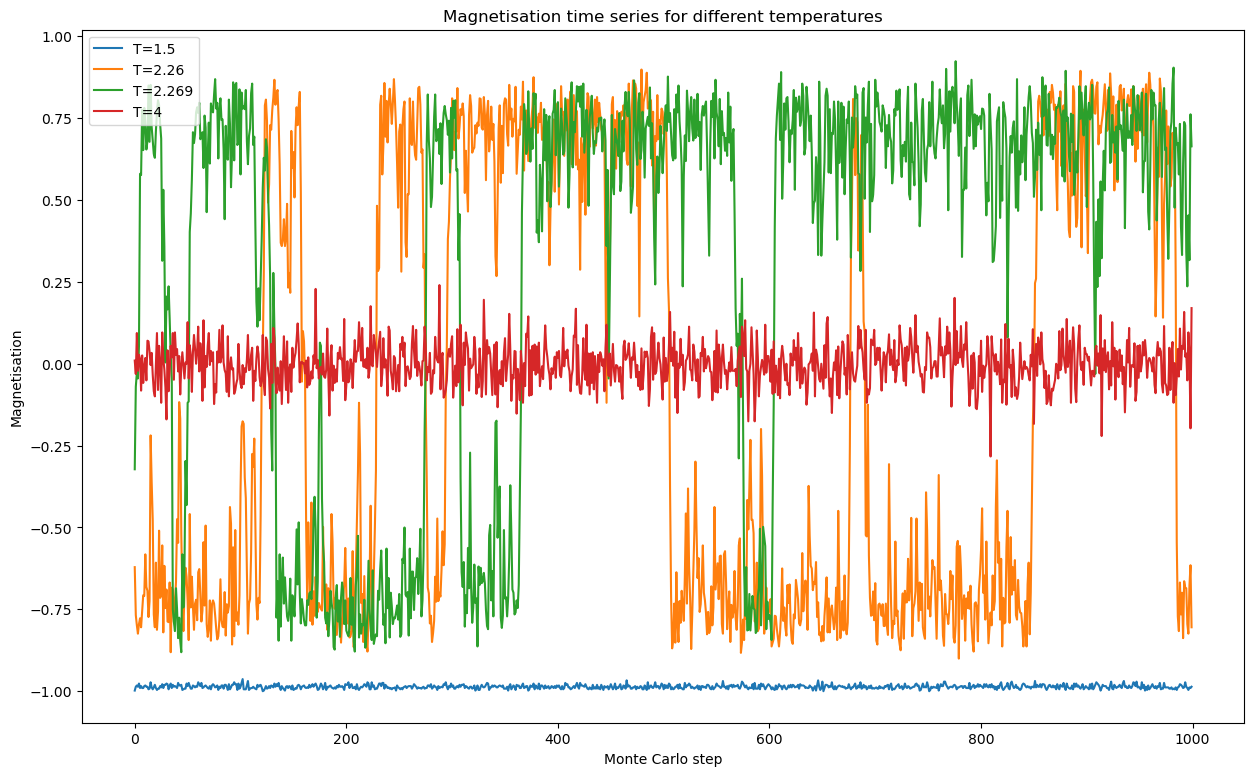

In [5]:
#PLOT MAGNETISATION (MARKET SENTIMENT) AT DIFFERENT TEMPERATURES 

plot_t = [1.5, 2.26, 2.269, 4]


def plot_amount(arr,num=100):
    size = arr.size
    if size >= 100:
        sampled_val = int(size/num)
    else:
        sampled_val = 1

    return sampled_val 
 

plt.figure(figsize=(15, 9))
for t in plot_t:
    sampled_val = plot_amount(results[t]["Magnetisation"],1000)  
    plt.plot(results[t]["Magnetisation"][::sampled_val], label=f"T={t}")
plt.xlabel("Monte Carlo step")
plt.ylabel("Magnetisation")
plt.title("Magnetisation time series for different temperatures")
plt.legend()
plt.show()

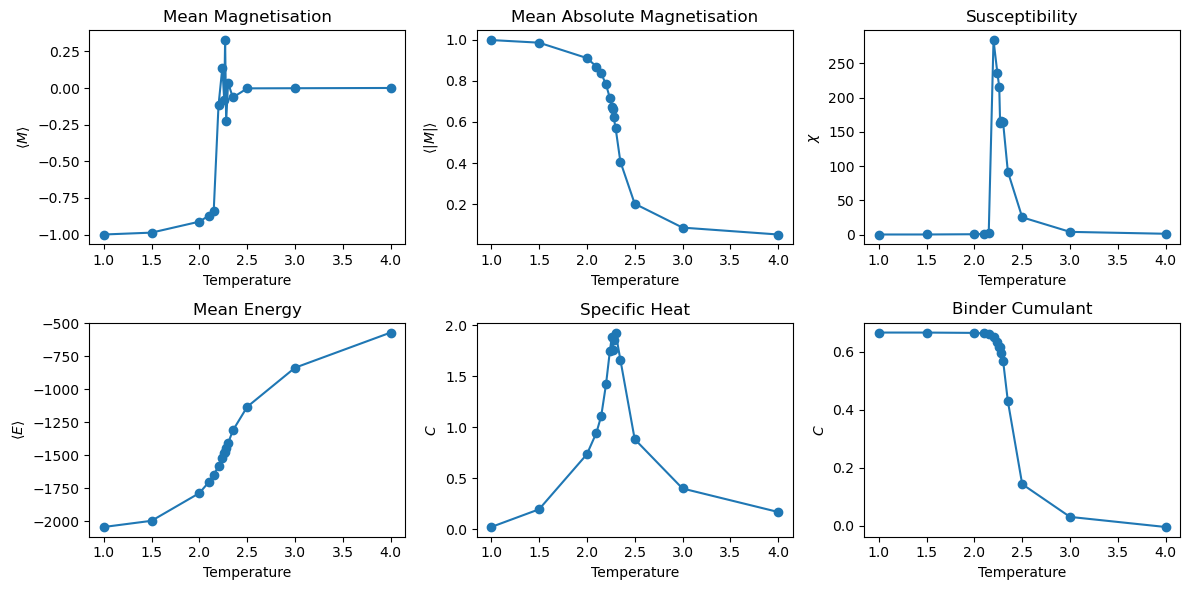

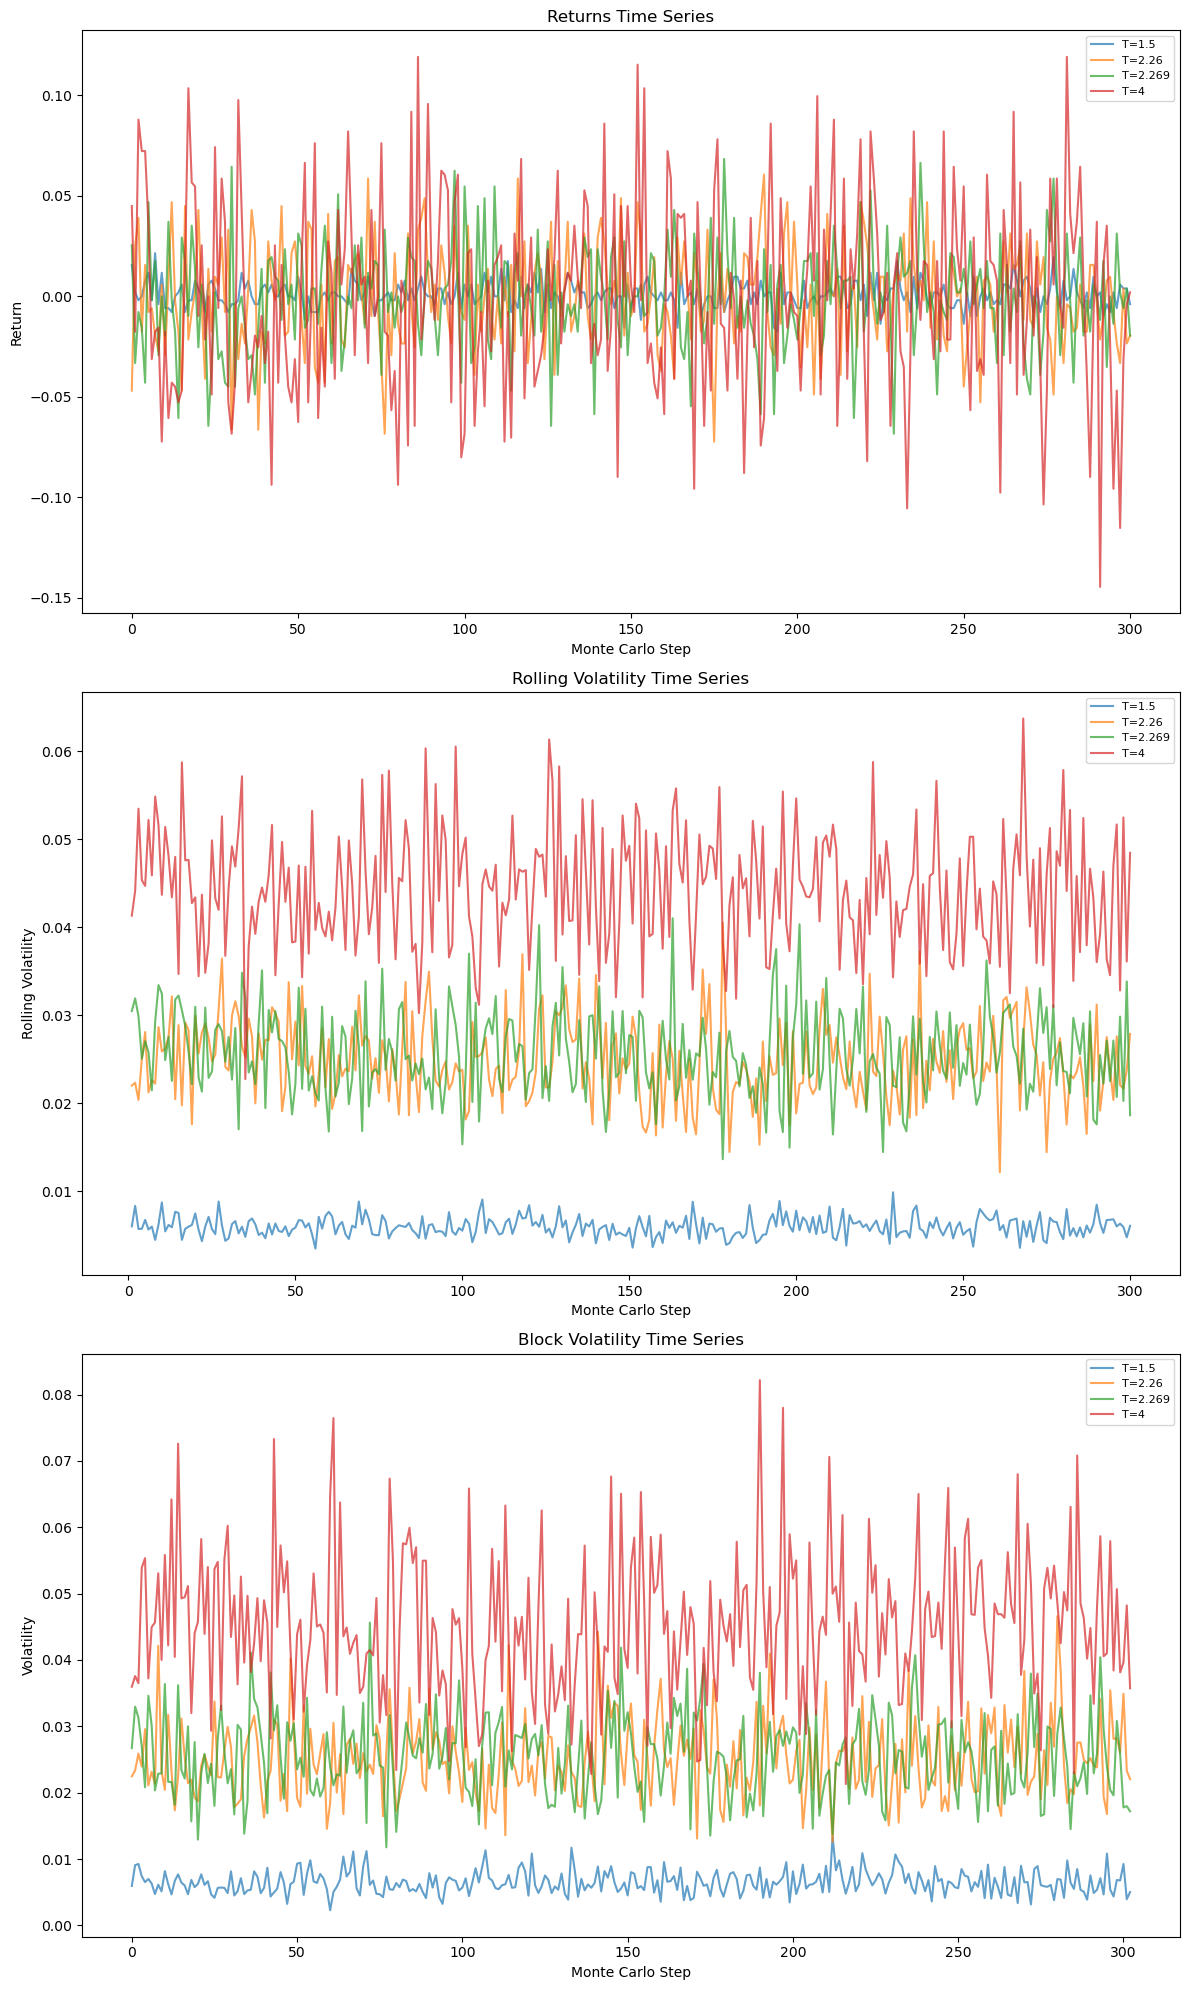

In [10]:

#EXTRACT VALUES INTO LISTS FOR PLOTTING 

average_mag = []
abs_average_mag = []
susceptibility = []
average_energy = []
specific_heat = []
first_returns = []
abs_first_return = []
binder_cumulant = []


for t in temps:
    average_mag.append(results[t]["Average_Mag"])
    abs_average_mag.append(results[t]["Abs_Average_Mag"])
    susceptibility.append(results[t]["Susceptibility"])
    average_energy.append(np.mean(results[t]["Energies"]).item())
    specific_heat.append(results[t]["Heat_Capacity"])
    binder_cumulant.append(results[t]["Binder_Cumulant"])
    

#PLOT DIFFERENT METRICS 

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

# 1. Mean Magnetisation
axes[0].plot(temps, average_mag, marker="o")
axes[0].set_title("Mean Magnetisation")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel(r"$\langle M \rangle$")

# 2. Mean Absolute Magnetisation
axes[1].plot(temps, abs_average_mag, marker="o")
axes[1].set_title("Mean Absolute Magnetisation")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel(r"$\langle |M| \rangle$")

# 3. Susceptibility
axes[2].plot(temps, susceptibility, marker="o")
axes[2].set_title("Susceptibility")
axes[2].set_xlabel("Temperature")
axes[2].set_ylabel(r"$\chi$")

# 4. Mean Energy
axes[3].plot(temps, average_energy, marker="o")
axes[3].set_title("Mean Energy")
axes[3].set_xlabel("Temperature")
axes[3].set_ylabel(r"$\langle E \rangle$")

# 5. Specific Heat
axes[4].plot(temps, specific_heat, marker="o")
axes[4].set_title("Specific Heat")
axes[4].set_xlabel("Temperature")
axes[4].set_ylabel(r"$C$")

# 6. Empty subplot (turn it off so it doesn't look stupid)
axes[5].plot(temps, binder_cumulant, marker="o")
axes[5].set_title("Binder Cumulant")
axes[5].set_xlabel("Temperature")
axes[5].set_ylabel(r"$C$")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Left: Returns
sampled_val = plot_amount(results[t]["First_Return"],300)  
for t in plot_t:
    axes[0].plot(results[t]["First_Return"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[0].set_title("Returns Time Series")
axes[0].set_xlabel("Monte Carlo Step")
axes[0].set_ylabel("Return")
axes[0].legend(fontsize=8)

# Right: Rolling Volatility
sampled_val = plot_amount(results[t]["Rolling_Vol"],300)  
for t in plot_t:
    axes[1].plot(results[t]["Rolling_Vol"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[1].set_title("Rolling Volatility Time Series")
axes[1].set_xlabel("Monte Carlo Step")
axes[1].set_ylabel("Rolling Volatility")
axes[1].legend(fontsize=8)

sampled_val = plot_amount(results[t]["Non_Rol_Vol"],300)  
for t in plot_t:
    axes[2].plot(results[t]["Non_Rol_Vol"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[2].set_title("Block Volatility Time Series")
axes[2].set_xlabel("Monte Carlo Step")
axes[2].set_ylabel("Volatility")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

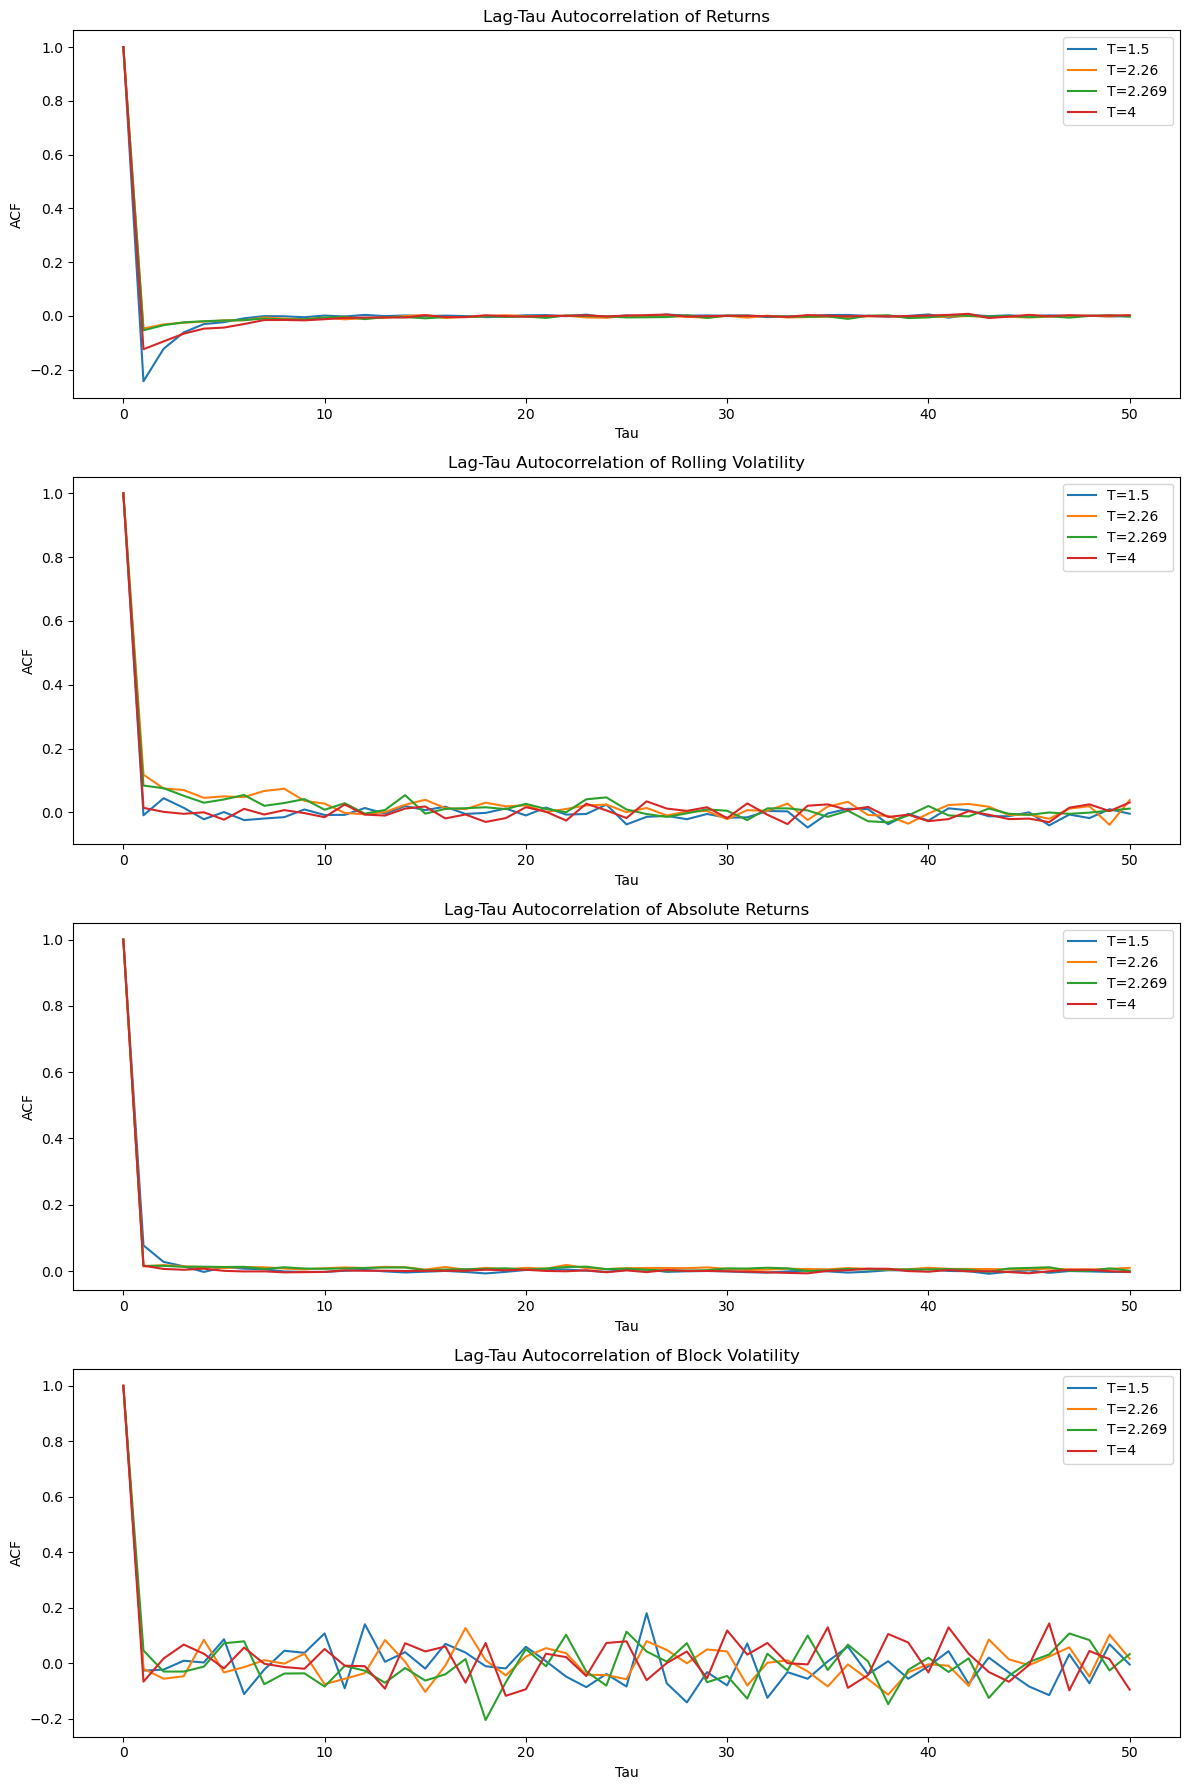

In [7]:
#COMPUTE AND PLOT ACF (mag,returns,abs return), CORRELATION TIME, KURTOSIS


#calculate lag-Tau auto-correlation for Tau up to max_lag




def autocorrelation_function(x, max_lag):
    x = np.asarray(x)
    x = x - np.mean(x)
    N = len(x)
    
    acf = np.zeros(max_lag + 1)
    
    var = np.var(x)
    
    for tau in range(max_lag + 1):
        cov = np.sum(x[:N - tau] * x[tau:]) / (N - tau)
        acf[tau] = cov / var
        
    return acf

acf = {}

for t in temps:
    m = np.array(results[t]["Magnetisation"])
    r = np.array(results[t]["First_Return"])
    abs_r = np.abs(r)
    rolling_vol_val = np.array(results[t]["Rolling_Vol"][::sampled_val])
    rolling_vol_val = rolling_vol_val[~np.isnan(rolling_vol_val)] # remove NAN values from rolling vol_val so autocorrelation works 
    block_vol_val = np.array(results[t]["Non_Rol_Vol"][::sampled_val])


    acf_m = autocorrelation_function(m, 50)
    acf_r = autocorrelation_function(r, 50)
    acf_abs_r = autocorrelation_function(abs_r, 50)
    acf_rolling_vol = autocorrelation_function(rolling_vol_val, 50)
    acf_block_vol = autocorrelation_function(block_vol_val, 50)

    acf[t] = {"acf_m":acf_m,"acf_r":acf_r,"acf_abs_r":acf_abs_r ,"acf_rolling_vol":acf_rolling_vol, "acf_block_vol": acf_block_vol }


#Plot AutoCorrelation values for Tau

fig, axes = plt.subplots(4, 1, figsize=(12, 18))
axes = axes.flatten()



for t in plot_t:
    axes[0].plot(acf[t]["acf_r"], label=f"T={t}")
    axes[1].plot(acf[t]["acf_rolling_vol"], label=f"T={t}")
    axes[2].plot(acf[t]["acf_abs_r"], label=f"T={t}")
    axes[3].plot(acf[t]["acf_block_vol"], label=f"T={t}")


axes[0].set_xlabel("Tau")
axes[0].set_ylabel("ACF")
axes[0].set_title("Lag-Tau Autocorrelation of Returns")
axes[0].legend()

axes[1].set_xlabel("Tau")
axes[1].set_ylabel("ACF")
axes[1].set_title("Lag-Tau Autocorrelation of Rolling Volatility")
axes[1].legend()

axes[2].set_xlabel("Tau")
axes[2].set_ylabel("ACF")
axes[2].set_title("Lag-Tau Autocorrelation of Absolute Returns")
axes[2].legend()

axes[3].set_xlabel("Tau")
axes[3].set_ylabel("ACF")
axes[3].set_title("Lag-Tau Autocorrelation of Block Volatility")
axes[3].legend()

plt.tight_layout()
plt.show()

